# ELA 错误级别分析


1. ELA 的基本原理；
2. JPEG 压缩中的 DCT、量化、反量化；
3. ELA 公式与代码对应关系；
4. 使用 Python 实现 ELA；
5. 基于 ELA 的简单图像篡改区域检测。

适合用于图像篡改方向入门分享。

## 1. ELA 的核心思想

ELA，全称 Error Level Analysis，错误级别分析。

它的核心假设是：

> 如果一张 JPEG 图像中某些区域被篡改过，那么这些区域和原始区域可能具有不同的压缩历史。  
> 对图像重新进行 JPEG 压缩后，不同区域的压缩误差会不一样。  
> 通过比较原图和重压缩图之间的差异，可以放大这种不一致。

简单来说：

```text
原图 I
  ↓ 重新 JPEG 压缩
重压缩图 JPEG_Q(I)
  ↓ 计算差异
ELA 图 E = |I - JPEG_Q(I)|

在ELA 图越亮的区域，表示该区域在重压缩过程中产生的误差越大。


## 2. ELA 公式

设原始图像为：

$$
I(x, y, c)
$$

其中：

- $x, y$ 表示像素坐标；
- $c$ 表示颜色通道，例如 R、G、B。

用固定 JPEG 质量 $Q$ 对图像重新压缩：

$$
\hat{I}_Q = JPEG_Q(I)
$$

错误级别图定义为：

$$
E(x, y, c) = |I(x, y, c) - \hat{I}_Q(x, y, c)|
$$

灰度 ELA：

$$
E_g(x, y) = \frac{1}{3} \sum_{c \in \{R,G,B\}} E(x, y, c)
$$

可视化增强：

$$
V(x, y) = clip(\alpha E_g(x, y), 0, 255)
$$

其中：

- $\alpha$ 是放大系数；
- 常用值为 10、15、20；
- $\alpha$ 越大，差异越明显，但噪声也会被放大。

## 3. JPEG 压缩流程：DCT、量化、反量化

JPEG 压缩和解压是两个过程。

### 编码压缩流程

```text
原图像素
  ↓
8x8 分块
  ↓
DCT
  ↓
量化
  ↓
熵编码
  ↓
保存为 .jpg

解码重建流程

.jpg 文件
  ↓
熵解码
  ↓
反量化
  ↓
IDCT
  ↓
重建图像

## 4. 量化、反量化与误差来源

在 JPEG 压缩中，DCT 本身是一种可逆变换，真正引入主要损失的是**量化**。

设某个 8×8 图像块的 DCT 系数为：

$$
C(u,v)
$$

对应位置的量化步长为：

$$
Q(u,v)
$$

量化过程可以简化表示为：

$$
C_q(u,v) = round \left( \frac{C(u,v)}{Q(u,v)} \right)
$$



在 JPEG 解码重建时，需要进行反量化：

$$
\hat{C}(u,v) = C_q(u,v) \cdot Q(u,v)
$$



量化误差可以表示为：

$$
error(u,v) = |C(u,v) - \hat{C}(u,v)|
$$


In [2]:

# 使用 OpenCV 演示一个 8x8 图像块的 DCT -> 量化 -> 反量化 -> IDCT

import cv2
import numpy as np

np.random.seed(0)

# 构造一个 8x8 像素块
block = np.random.randint(80, 180, size=(8, 8), dtype=np.uint8).astype(np.float32)

# JPEG DCT 前通常做 level shift，减去 128
block_shifted = block - 128.0

# 简化的量化表，这里全部设为 16
Q = np.ones((8, 8), dtype=np.float32) * 16.0

# 1. DCT
dct_coeffs = cv2.dct(block_shifted)

# 2. 量化
dct_quantized = np.round(dct_coeffs / Q)

# 3. 反量化
dct_dequantized = dct_quantized * Q

# 4. IDCT
block_reconstructed = cv2.idct(dct_dequantized) + 128.0
block_reconstructed = np.clip(block_reconstructed, 0, 255)

# 计算重建误差
mae = np.abs(block - block_reconstructed).mean()

print("原始 8x8 像素块：")
print(block)

print("\nDCT 系数左上角 4x4：")
print(dct_coeffs[:4, :4])

print("\n量化后 DCT 系数左上角 4x4：")
print(dct_quantized[:4, :4])

print("\n反量化后 DCT 系数左上角 4x4：")
print(dct_dequantized[:4, :4])

print("\n重建像素块：")
print(block_reconstructed)

print("\n平均绝对重建误差 MAE:")
print(mae)

原始 8x8 像素块：
[[124.  90.  92. 127. 122. 148. 103. 118.]
 [102. 135. 144. 156. 113. 168. 147. 131.]
 [158. 106. 162. 114. 171. 147.  91. 168.]
 [ 89. 116. 163. 174. 113. 111. 101. 161.]
 [169. 117. 166. 178. 116. 135.  85. 167.]
 [138. 123. 156. 150. 140. 155. 168. 141.]
 [ 84.  94. 168. 106. 130.  92. 157. 156.]
 [149. 138. 137. 121. 178. 145. 146. 152.]]

DCT 系数左上角 4x4：
[[ 53.749996  -32.966156  -25.492258  -43.186848 ]
 [-34.86127     7.892418  -16.982021   20.1971   ]
 [-25.463896  -31.962305    5.6020284  59.793232 ]
 [-19.6546     -2.9119997   1.3259697   9.563369 ]]

量化后 DCT 系数左上角 4x4：
[[ 3. -2. -2. -3.]
 [-2.  0. -1.  1.]
 [-2. -2.  0.  4.]
 [-1. -0.  0.  1.]]

反量化后 DCT 系数左上角 4x4：
[[ 48. -32. -32. -48.]
 [-32.   0. -16.  16.]
 [-32. -32.   0.  64.]
 [-16.  -0.   0.  16.]]

重建像素块：
[[119.87775   88.55246   92.67114  125.82654  115.52323  154.46176
  104.15097  112.54624 ]
 [ 90.37871  140.8127   143.47604  160.01663  117.728584 167.53151
  142.89325  134.16234 ]
 [157.70447   97.94

## 6. ELA 公式到代码的映射

| 公式 | 代码 |
|---|---|
| $\hat{I}_Q = JPEG_Q(I)$ | `img.save(buf, format="JPEG", quality=quality)` |
| $E = |I - \hat{I}_Q|$ | `E = np.abs(I - J)` |
| $E_g = mean(E)$ | `E_gray = E.mean(axis=2)` |
| $V = clip(\alpha E_g, 0, 255)$ | `V = np.clip(scale * E_gray, 0, 255).astype(np.uint8)` |

In [3]:
# 导入基础库

import os
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import cv2

%matplotlib inline

## 7. 定义 ELA 基础函数

下面定义三个函数：

1. `load_rgb(path)`：读取图像；
2. `jpeg_recompress(img, quality)`：对图像进行 JPEG 重压缩；
3. `compute_ela(orig_img, re_img, scale)`：计算 ELA。

In [1]:
import cv2
import numpy as np


def jpeg_compress_decompress_opencv(img_rgb, quality=90):
    """
    对 RGB 图像进行真实 JPEG 压缩和解码。

    输入:
        img_rgb: RGB 图像, shape = [H, W, 3]
        quality: JPEG 压缩质量, 0 ~ 100

    输出:
        重压缩后的 RGB 图像, float32, shape = [H, W, 3]
    """

    # 保证输入是 uint8
    img = np.clip(img_rgb, 0, 255).astype(np.uint8)

    # RGB 转 BGR，因为 OpenCV 默认使用 BGR
    if img.ndim == 2:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # JPEG 编码参数
    params = [
        int(cv2.IMWRITE_JPEG_QUALITY),
        int(quality)
    ]

    # 尽量使用 4:4:4，减少色度采样带来的额外差异
    # 不是所有 OpenCV 版本都有这个常量，所以加 try
    try:
        params += [
            int(cv2.IMWRITE_JPEG_SAMPLING_FACTOR),
            int(cv2.IMWRITE_JPEG_SAMPLING_FACTOR_444)
        ]
    except AttributeError:
        pass

    # 真实 JPEG 编码
    ok, encoded = cv2.imencode(".jpg", img_bgr, params)

    if not ok:
        raise RuntimeError("JPEG 编码失败")

    # 得到 JPEG 字节流
    jpg_bytes = encoded.tobytes()

    # 真实 JPEG 解码
    decoded_bgr = cv2.imdecode(
        np.frombuffer(jpg_bytes, dtype=np.uint8),
        cv2.IMREAD_COLOR
    )

    if decoded_bgr is None:
        raise RuntimeError("JPEG 解码失败")

    # BGR 转回 RGB
    decoded_rgb = cv2.cvtColor(decoded_bgr, cv2.COLOR_BGR2RGB)

    return decoded_rgb.astype(np.float32)

In [3]:
def load_rgb(path):
    """
    读取图像并转为 RGB。
    使用 PIL 读取，对中文路径更友好。
    """
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)
    return img.convert("RGB")


def jpeg_recompress(img, quality=90):
    """
    对图像进行 JPEG 重压缩。

    对应公式：
        I_hat_Q = JPEG_Q(I)
    """
    buf = BytesIO()
    img.save(
        buf,
        format="JPEG",
        quality=quality,
        subsampling=0  # 4:4:4，减少色度采样带来的额外干扰
    )
    buf.seek(0)
    return Image.open(buf).convert("RGB")


def compute_ela(orig_img, quality=90, scale=15.0):
    """
    使用真实 JPEG 压缩计算 ELA。

    对应公式：
        E(x, y, c) = |I(x, y, c) - JPEG_Q(I)(x, y, c)|
        E_gray(x, y) = mean_c E(x, y, c)
        V(x, y) = clip(scale * E_gray(x, y), 0, 255)
    """

    # 原图 I
    I = np.asarray(orig_img, dtype=np.float32)

    # 如果是灰度图，先转成 RGB
    if I.ndim == 2:
        I_uint8 = np.clip(I, 0, 255).astype(np.uint8)
        I = cv2.cvtColor(I_uint8, cv2.COLOR_GRAY2RGB).astype(np.float32)

    # 重压缩图 JPEG_Q(I)
    # 真实 JPEG 编码 + 解码
    J = jpeg_compress_decompress_opencv(I, quality=quality)

    # 错误级别图：E = |I - J|
    E = np.abs(I - J)

    # 灰度错误图：E_gray = mean over RGB channels
    E_gray = E.mean(axis=2)

    # 可视化增强：V = clip(scale * E_gray, 0, 255)
    V_gray = np.clip(scale * E_gray, 0, 255).astype(np.uint8)

    # 彩色增强版本
    V_color = np.clip(scale * E, 0, 255).astype(np.uint8)

    return E, E_gray, V_gray, V_color, J

## 8. 准备测试图像

如果你已经有 JPEG 图像，可以直接修改下面的：

```python
IMAGE_PATH = "your_image.jpg"
CREATE_DEMO_IF_MISSING = False

In [14]:
# 参数设置与 demo 生成（修正版）

# 原始图像路径
ORIGINAL_IMAGE_PATH = "demo.jpg"

# 篡改后的待检测图像路径
TAMPER_IMAGE_PATH = "demo_tamper.jpg"

# 实际做 ELA 和篡改检测时，分析的是待检测图像
ANALYSIS_IMAGE_PATH = TAMPER_IMAGE_PATH

# JPEG 重压缩质量
QUALITY = 90

# ELA 放大系数
SCALE = 15.0

# 如果图像不存在，是否自动生成 demo 图像
CREATE_DEMO_IF_MISSING = True

# 是否强制重新生成 demo 图像
# 如果你想重新生成 demo.jpg 和 demo_tamper.jpg，设置为 True
FORCE_RECREATE_DEMO = False


def make_demo_image(path="demo.jpg", size=(640, 480)):
    """
    生成一张简单的原始 demo 图像。
    """
    w, h = size

    x = np.linspace(0, 255, w, dtype=np.uint8)
    y = np.linspace(0, 255, h, dtype=np.uint8)

    xx, yy = np.meshgrid(x, y)

    r = xx
    g = yy
    b = ((xx.astype(np.uint16) + yy.astype(np.uint16)) // 2).astype(np.uint8)

    img_rgb = np.stack([r, g, b], axis=2)

    # 使用 OpenCV 画一些形状
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    cv2.rectangle(img_bgr, (70, 70), (220, 220), (255, 255, 255), -1)
    cv2.circle(img_bgr, (430, 300), 80, (0, 0, 255), -1)
    cv2.putText(
        img_bgr,
        "ELA",
        (260, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    Image.fromarray(img_rgb).save(
        path,
        format="JPEG",
        quality=85,
        subsampling=0
    )

    return path


def make_demo_tamper(src_path="demo.jpg", dst_path="demo_tamper.jpg"):
    """
    生成一个简单篡改 demo：

    1. 读取原始图像 demo.jpg；
    2. 取一个 patch；
    3. 对 patch 单独低质量 JPEG 压缩；
    4. 粘贴回原图；
    5. 整体保存为 demo_tamper.jpg。
    """
    img = Image.open(src_path).convert("RGB")
    arr = np.asarray(img)

    # 取一个 patch
    y1, y2 = 60, 180
    x1, x2 = 360, 480

    patch = arr[y1:y2, x1:x2].copy()
    patch_img = Image.fromarray(patch)

    # 对 patch 单独低质量压缩，模拟不同压缩历史
    buf = BytesIO()
    patch_img.save(
        buf,
        format="JPEG",
        quality=20,
        subsampling=0
    )
    buf.seek(0)

    patch_low_quality = Image.open(buf).convert("RGB")

    # 粘贴到新位置
    img.paste(patch_low_quality, (200, 260))

    # 整体保存为篡改图
    img.save(
        dst_path,
        format="JPEG",
        quality=85,
        subsampling=0
    )

    return dst_path


if CREATE_DEMO_IF_MISSING:
    if FORCE_RECREATE_DEMO or not os.path.exists(ORIGINAL_IMAGE_PATH):
        make_demo_image(ORIGINAL_IMAGE_PATH)

    if FORCE_RECREATE_DEMO or not os.path.exists(TAMPER_IMAGE_PATH):
        make_demo_tamper(ORIGINAL_IMAGE_PATH, TAMPER_IMAGE_PATH)

print("原始图像路径:", ORIGINAL_IMAGE_PATH)
print("原始图像是否存在:", os.path.exists(ORIGINAL_IMAGE_PATH))

print("\n篡改图像路径:", TAMPER_IMAGE_PATH)
print("篡改图像是否存在:", os.path.exists(TAMPER_IMAGE_PATH))

print("\n实际分析图像路径:", ANALYSIS_IMAGE_PATH)

原始图像路径: demo.jpg
原始图像是否存在: True

篡改图像路径: demo_tamper.jpg
篡改图像是否存在: True

实际分析图像路径: demo_tamper.jpg


## 9. 运行 ELA 可视化

下面代码会：

1. 读取图像；
2. 对图像进行 JPEG 重压缩；
3. 计算 ELA；
4. 显示原图、重压缩图、ELA 图。

===== 原始图像 ELA 统计信息 =====
图像尺寸: (480, 640, 3)
平均绝对误差 MAE: 0.2601
最大像素误差: 42.0000
ELA 灰度图均值: 0.2601
ELA 灰度图最大值: 20.6667

===== 篡改图像 ELA 统计信息 =====
图像尺寸: (480, 640, 3)
平均绝对误差 MAE: 0.2601
最大像素误差: 42.0000
ELA 灰度图均值: 0.2601
ELA 灰度图最大值: 20.6667


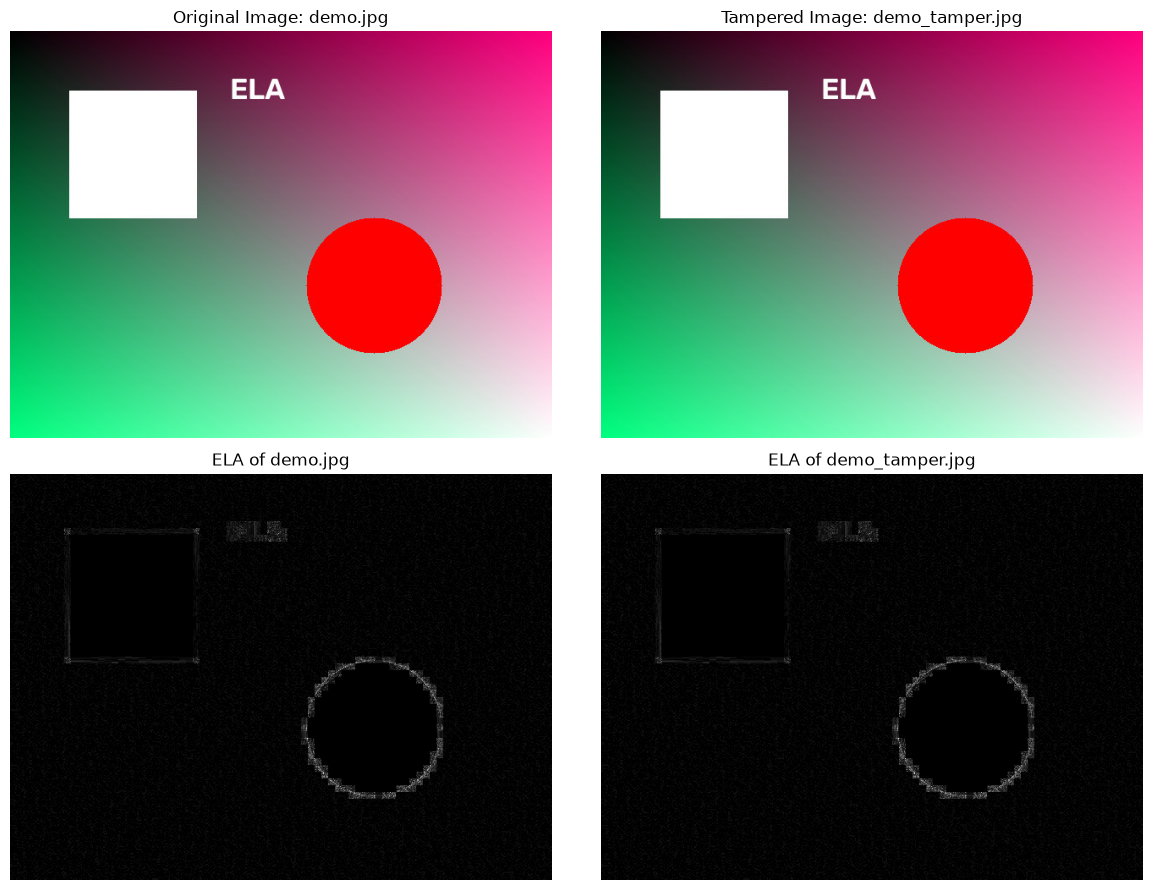

In [15]:
# 读取原始图和篡改图，并分别做 ELA（修正版）

# 读取原始图像
img_original = load_rgb(ORIGINAL_IMAGE_PATH)

# 读取篡改图像
img_tamper = load_rgb(TAMPER_IMAGE_PATH)

# 对原始图像做 ELA，用于对比
re_original = jpeg_recompress(img_original, quality=QUALITY)
E_original, E_gray_original, V_gray_original, V_color_original = compute_ela(
    img_original,
    re_original,
    scale=SCALE
)

# 对篡改图像做 ELA，这是实际分析目标
re_tamper = jpeg_recompress(img_tamper, quality=QUALITY)
E_tamper, E_gray_tamper, V_gray_tamper, V_color_tamper = compute_ela(
    img_tamper,
    re_tamper,
    scale=SCALE
)

# 打印统计信息
print("===== 原始图像 ELA 统计信息 =====")
print(f"图像尺寸: {np.asarray(img_original).shape}")
print(f"平均绝对误差 MAE: {E_original.mean():.4f}")
print(f"最大像素误差: {E_original.max():.4f}")
print(f"ELA 灰度图均值: {E_gray_original.mean():.4f}")
print(f"ELA 灰度图最大值: {E_gray_original.max():.4f}")

print("\n===== 篡改图像 ELA 统计信息 =====")
print(f"图像尺寸: {np.asarray(img_tamper).shape}")
print(f"平均绝对误差 MAE: {E_tamper.mean():.4f}")
print(f"最大像素误差: {E_tamper.max():.4f}")
print(f"ELA 灰度图均值: {E_gray_tamper.mean():.4f}")
print(f"ELA 灰度图最大值: {E_gray_tamper.max():.4f}")

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].imshow(np.asarray(img_original))
axes[0, 0].set_title(f"Original Image: {ORIGINAL_IMAGE_PATH}")

axes[0, 1].imshow(np.asarray(img_tamper))
axes[0, 1].set_title(f"Tampered Image: {TAMPER_IMAGE_PATH}")

axes[1, 0].imshow(V_gray_original, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title(f"ELA of {ORIGINAL_IMAGE_PATH}")

axes[1, 1].imshow(V_gray_tamper, cmap="gray", vmin=0, vmax=255)
axes[1, 1].set_title(f"ELA of {TAMPER_IMAGE_PATH}")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. 基于 ELA 的简单篡改识别

ELA 图的特点：
篡改区域可能更亮；
强边缘、纹理区域也可能较亮；
背景通常比较暗；
但 ELA 图本身只是灰度响应图，不是最终 mask。

下面代码实现一个简单的篡改区域检测流程：

```text
计算 ELA
  ↓
高斯模糊
  ↓
阈值分割
  ↓
形态学去噪
  ↓
查找连通域
  ↓
过滤小区域
  ↓
画出可疑框

In [8]:

def load_rgb_array(path):
    """
    读取图像并返回 RGB numpy 数组。
    """
    return np.asarray(load_rgb(path), dtype=np.uint8)


def compute_ela_gray_array(img_rgb, quality=90, scale=15.0):
    """
    输入 RGB numpy 图像，输出灰度 ELA。
    """

    pil_img = Image.fromarray(img_rgb)

    # JPEG 重压缩
    buf = BytesIO()
    pil_img.save(
        buf,
        format="JPEG",
        quality=quality,
        subsampling=0
    )
    buf.seek(0)

    re_img = Image.open(buf).convert("RGB")
    re_rgb = np.asarray(re_img, dtype=np.float32)

    orig = img_rgb.astype(np.float32)

    # E = |I - JPEG_Q(I)|
    E = np.abs(orig - re_rgb)

    # E_gray = mean over RGB channels
    E_gray = E.mean(axis=2)

    # V = clip(scale * E_gray, 0, 255)
    V = np.clip(scale * E_gray, 0, 255).astype(np.uint8)

    return V, E


def detect_tamper_simple(
    img_rgb,
    quality=90,
    scale=15.0,
    z=3.0,
    min_area=None
):
    """
    基于 ELA 的简单篡改区域检测。
    """

    h, w = img_rgb.shape[:2]

    if min_area is None:
        # 默认最小面积：图像面积的 0.05%，但至少 300 像素
        min_area = max(300, int(h * w * 0.0005))

    # 1. 计算 ELA
    ela, E = compute_ela_gray_array(
        img_rgb,
        quality=quality,
        scale=scale
    )

    # 2. 高斯模糊，降低噪点
    blur = cv2.GaussianBlur(ela, (5, 5), 0)

    # 3. 统计阈值：T = mean + z * std
    mu_arr, std_arr = cv2.meanStdDev(blur)
    mu = float(mu_arr[0, 0])
    std = float(std_arr[0, 0])
    stat_thresh = mu + z * std

    # 4. Otsu 阈值
    otsu_thresh, _ = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 5. 最终阈值取两者中更大的，降低误报
    final_thresh = max(float(otsu_thresh), float(stat_thresh))
    final_thresh = float(np.clip(final_thresh, 0, 255))

    # 6. 二值化
    _, mask = cv2.threshold(
        blur,
        final_thresh,
        255,
        cv2.THRESH_BINARY
    )

    # 7. 形态学处理
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

    # 闭运算：连接断裂区域
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 开运算：去除小噪点
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # 8. 查找轮廓
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # 9. 画框
    result_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    boxes = []

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area < min_area:
            continue

        x, y, bw, bh = cv2.boundingRect(cnt)

        cv2.rectangle(
            result_bgr,
            (x, y),
            (x + bw, y + bh),
            (0, 0, 255),
            2
        )

        boxes.append({
            "x": int(x),
            "y": int(y),
            "w": int(bw),
            "h": int(bh),
            "area": float(area)
        })

    info = {
        "image_size": [int(w), int(h)],
        "mean_abs_error": float(E.mean()),
        "mean_ela": float(ela.mean()),
        "blur_mean": mu,
        "blur_std": std,
        "otsu_thresh": float(otsu_thresh),
        "stat_thresh": float(stat_thresh),
        "final_thresh": final_thresh,
        "min_area": int(min_area),
        "num_suspects": len(boxes)
    }

    return result_bgr, mask, ela, boxes, info

===== 检测信息 =====
image_size: [640, 480]
mean_abs_error: 0.2600748836994171
mean_ela: 3.9006966145833335
blur_mean: 3.9024348958333337
blur_std: 6.748144946362342
otsu_thresh: 25.0
stat_thresh: 24.14686973492036
final_thresh: 25.0
min_area: 300
num_suspects: 4

===== 可疑区域 =====
suspect #1: {'x': 345, 'y': 309, 'w': 167, 'h': 76, 'area': 2164.5}
suspect #2: {'x': 440, 'y': 217, 'w': 72, 'h': 73, 'area': 903.5}
suspect #3: {'x': 351, 'y': 215, 'w': 83, 'h': 71, 'area': 929.5}
suspect #4: {'x': 258, 'y': 56, 'w': 70, 'h': 25, 'area': 976.5}


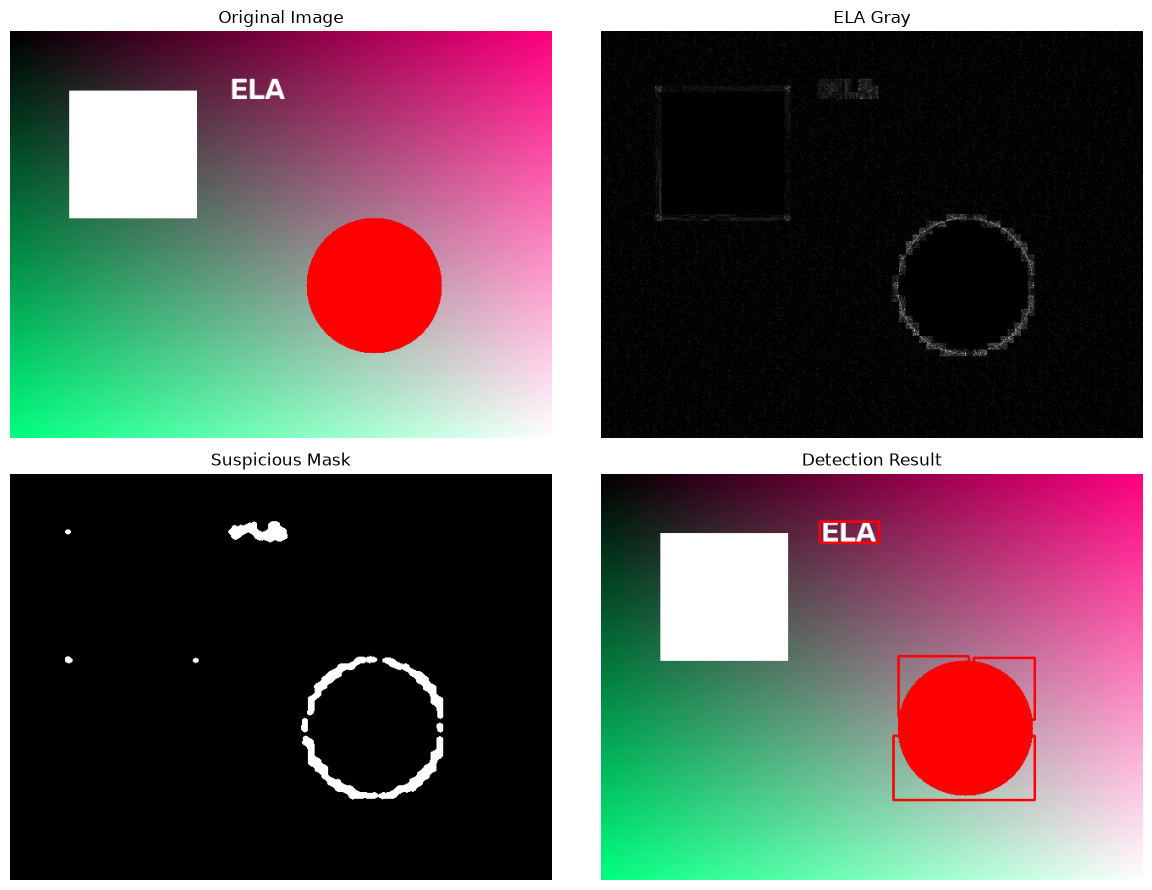

In [16]:
# 读取图像
img_rgb = load_rgb_array(IMAGE_PATH)

# 检测可疑区域
result_bgr, mask, ela, boxes, info = detect_tamper_simple(
    img_rgb,
    quality=QUALITY,
    scale=SCALE,
    z=3.0
)

# 打印检测信息
print("===== 检测信息 =====")
for k, v in info.items():
    print(f"{k}: {v}")

print("\n===== 可疑区域 =====")
if len(boxes) == 0:
    print("未发现明显可疑区域。")
else:
    for i, box in enumerate(boxes, 1):
        print(f"suspect #{i}: {box}")

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")

axes[0, 1].imshow(ela, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("ELA Gray")

axes[1, 0].imshow(mask, cmap="gray")
axes[1, 0].set_title("Suspicious Mask")

axes[1, 1].imshow(cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Detection Result")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 15. ELA 的局限性

ELA 虽然简单有效，但有很多限制：

1. 对非 JPEG 图像效果有限；
2. 对多次压缩图像容易误报；
3. 对社交平台二次压缩后的图像不稳定；
4. 对同图复制粘贴 copy-move 不一定敏感；
5. 只能反映压缩不一致，不能直接证明语义篡改；
6. 高质量压缩或弱篡改可能看不出来。

因此，ELA 更适合作为辅助取证方法。

## 16. 可扩展方向

如果作为方向专题分享，最后可以给出后续研究路线：

### 1. ELA + 噪声分析

- SPN；
- Noiseprint；
- SRM 滤波器；
- 相机传感器噪声。

### 2. ELA + 双 JPEG 压缩检测
：

- 第一次压缩质量估计；
- 双重压缩痕迹；
- DCT 系数直方图。

### 3. ELA + 深度学习

可以把 ELA 图作为辅助通道输入网络：

```text

用于：
图像拼接检测；
copy-move 检测；
人脸篡改检测；
AIGC 图像局部编辑检测。